<h2 style="color:blue" align="center">Wine Quality Prediction</h2>

#### Import the necessary libraries

In [1]:
import random as python_random
import time, math 
from tqdm import tqdm

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras 
from keras.models import Sequential
from keras.layers import Dense 
from keras.callbacks import Callback, CSVLogger 

import warnings
warnings.filterwarnings('ignore')

#### Reserve GPU memory for the execution

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

1 Physical GPUs, 1 Logical GPUs


#### Load the dataset

In [3]:
df = pd.read_csv('../Dataset/winequality-white.csv',sep=';')
df.shape

(4898, 12)

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
X = df.drop(['quality'],axis=1)
Y = df['quality']

#### Preprocess input

In [6]:
# Normalize the input dataset
scaler_MinMax = MinMaxScaler()
X = scaler_MinMax.fit_transform(X) 

#### Split the dataset into training and testing set

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2) 

In [8]:
X_train.shape

(3918, 11)

#### Define DNN model

In [9]:
python_random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)
opti_name = ''

def get_model(): 
    tf.keras.backend.clear_session()
    model = Sequential([ 
        Dense(1, input_dim = 11, activation='linear') 
    ], name = "DNN_model")
    
    global opti_name 
    
    # General SGD
    opti = keras.optimizers.SGD(learning_rate=0.001)
    opti_name = 'SGD'
    
    # Momentum
    #opti = keras.optimizers.SGD(learning_rate=0.001, momentum=0.6)
    #opti_name = 'Momentum'
    
    # Nesterov Accelerated Gradient 
    #opti = keras.optimizers.SGD(learning_rate=0.001, momentum=0.4, nesterov=True)
    #opti_name = 'NAG'
    
    # Adagrad
    #opti = keras.optimizers.Adagrad(learning_rate=0.001) 
    #opti_name = 'AdaGrad' 
    
    # RMSprop 
    #opti = keras.optimizers.RMSprop(learning_rate=0.001)
    #opti_name = 'RMSprop'
    
    # Adadelta
    #opti = keras.optimizers.Adadelta(learning_rate=0.001) 
    #opti_name = 'AdaDelta' 
    
    # Adam
    #opti = keras.optimizers.Adam(learning_rate=0.001) 
    #opti_name = 'Adam'     
    
    # Adamax
    #opti = keras.optimizers.Adamax(learning_rate=0.001) 
    #opti_name = 'AdaMax'
    
    # Nadam
    #opti = keras.optimizers.Nadam(learning_rate=0.001) 
    #opti_name = 'Nadam'  
    
    model.compile(
        optimizer = opti,
        loss = 'mse'  
    )
    
    return model

#### Custom callbacks

HMS

In [10]:
class CustomCallbackHMS(Callback):  
    initial_weights = 0
    previous_weights = 0
    call_hm = 0 
    temp_model = 0
    r = 1
    t = 100
    
    def __init__(self, mod):
        self.temp_model = mod
        
    def on_train_begin(self, logs=None):
        self.initial_weights = self.temp_model.get_weights() 
        self.initial_weights = np.array(self.initial_weights,dtype=object)
        self.previous_weights = self.initial_weights
        # Harmonic mean based weights calculation
        self.call_hm = np.vectorize(self.apply_hm)  
             
    def on_epoch_end(self, epoch, logs={}):    
        # Minimizing HMS factor every 100 epoch
        if (epoch+1)%self.t == 0:
            self.r = round(self.r *0.9,4)  
        
        num_layers = len(self.temp_model.layers)  
        current_weights = self.temp_model.get_weights()
        current_weights = np.array(current_weights,dtype=object)        

        for i in range(num_layers):  
            # Harmonic mean based weights calculation
            tensor1 = tf.convert_to_tensor(self.previous_weights[i])
            tensor2 = tf.convert_to_tensor(current_weights[i])
            current_weights[i] = self.call_hm(tensor1, tensor2, self.r)   
            
        # Updating the model with new weights
        self.temp_model.set_weights(current_weights.tolist())
        self.previous_weights = current_weights
        
    def apply_hm(self, v1, v2, r): 
        # HMS calculation   
        if v1==0 or v2==0:
            return v2
        elif v1 > v2:
            t1 = abs(v1)
            t2 = abs(v2)
            hm = 2*t1*t2/(t1+t2)
            min1 = min(t1,t2)
            hms = abs(hm-min1)*r
            v2 = v2 - hms
            return v2  
        elif v1 < v2:
            t1 = abs(v1)
            t2 = abs(v2)
            hm = 2*t1*t2/(t1+t2)
            min1 = min(t1,t2)
            hms = abs(hm-min1)*r
            v2 = v2 + hms
            return v2   
        else:
            return v2   

#### Training

Get a model to assign same weights to model with and without HMS

In [11]:
model = get_model() 
weights = model.get_weights() 
num_epochs = 200
Full = X_train.shape[0]
batch_size = Full     # Full / 256 / 64 / 16

To record loss and accuracy in CSV file

In [12]:
generic_file = 'Results/Wine/'+ opti_name +' optimizer.csv'
hms_file = 'Results/Wine/'+ opti_name +' HMS optimizer.csv' 
logger_generic_model = CSVLogger(generic_file, append = False, separator=',')
logger_hms_model = CSVLogger(hms_file, append = False, separator=',')

Generic opimizer model

In [13]:
model_wihtout_hms = get_model()
model_wihtout_hms.set_weights(weights) 
st = time.time() 
model_wihtout_hms.fit(X_train, y_train, epochs = num_epochs, verbose=0, callbacks=[logger_generic_model], batch_size=batch_size) 
et = time.time()
elapsed_training_time_generic = round(et - st, 4)
print('Execution time:', elapsed_training_time_generic, 'seconds') 

Execution time: 0.6675 seconds


HMS-based optimizer model

In [14]:
model_with_hms = get_model()
model_with_hms.set_weights(weights) 
st = time.time()
model_with_hms.fit(X_train, y_train, epochs = num_epochs, verbose=0, callbacks=[CustomCallbackHMS(model_with_hms),logger_hms_model], batch_size=batch_size) 
et = time.time()
elapsed_training_time_hms = round(et - st, 4)
print('Execution time:', elapsed_training_time_hms, 'seconds') 

Execution time: 0.3871 seconds


Model summary

In [15]:
model_with_hms.summary()

Model: "DNN_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 12        
                                                                 
Total params: 12
Trainable params: 12
Non-trainable params: 0
_________________________________________________________________


#### Generic optimizer vs HMS-based optimizer

In [16]:
df1 = pd.read_csv(generic_file)
df2 = pd.read_csv(hms_file)

Loss

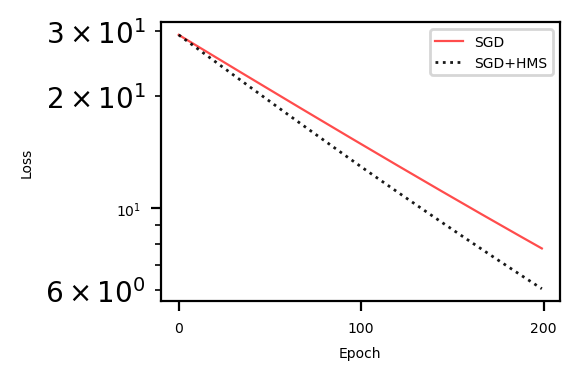

In [17]:
x1 = range(0, df1.shape[0])
x2 = range(0, df2.shape[0])
y1 = df1['loss'] 
y2 = df2['loss']  
plt.figure(figsize = (3,2), dpi = 200)
plt.plot(x1, y1, "r-", label = opti_name, linewidth = 0.8, alpha = 0.7)
plt.plot(x2, y2, "k:", label = opti_name+'+HMS', linewidth = 1, alpha = 0.9) 
plt.ylabel('Loss' , fontdict = {'fontsize':5})
plt.xlabel('Epoch', fontdict = {'fontsize':5}) 
plt.yscale('log')
#plt.title("Loss", fontdict = {'fontname':'Times New Roman', 'fontsize':8})
plt.xticks(fontsize = 5)
plt.yticks(fontsize = 5)
plt.tight_layout()
plt.legend(prop={'size': 5})
#plt.savefig("graph.png",bbox_inches='tight',dpi=(300)) 
plt.show()

#### Training cost

In [18]:
print(f'Taining cost on {opti_name} = {round(df1.iloc[num_epochs-1].loss, 3)}')
print(f'Taining cost on {opti_name}+HMS = {round(df2.iloc[num_epochs-1].loss, 3)}')

Taining cost on SGD = 7.78
Taining cost on SGD+HMS = 6.058


#### Testing the model

Generic opimizer model

In [19]:
generic_testing_cost = model_wihtout_hms.evaluate(X_test, y_test)
generic_testing_cost   

31/31 [==============================] - 0s 460us/step - loss: 7.9493


7.949275493621826

HMS-based optimizer model

In [20]:
hms_testing_cost = model_with_hms.evaluate(X_test, y_test)
hms_testing_cost 

31/31 [==============================] - 0s 537us/step - loss: 6.2052


6.20522928237915

<h2 style="color:blue" align="center">Training Loss vs Validation Loss</h2>

For generic optimizer

In [21]:
model_wihtout_hms_val = get_model()
model_wihtout_hms_val.set_weights(weights) 
history = model_wihtout_hms_val.fit(X_train, y_train, epochs = num_epochs, verbose=0, validation_split=0.2, batch_size=batch_size) 

In [22]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

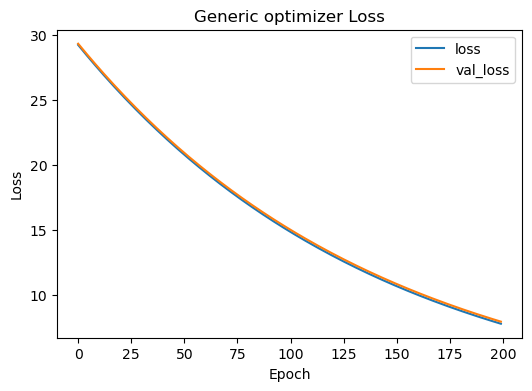

In [23]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Generic optimizer Loss')
#plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show()

For HMS-based optimizer

In [24]:
model_with_hms_val = get_model()
model_with_hms_val.set_weights(weights) 
history_hms = model_with_hms_val.fit(X_train, y_train, epochs = num_epochs, verbose=0, validation_split=0.2, callbacks=[CustomCallbackHMS(model_with_hms_val)], batch_size=batch_size) 

In [25]:
history_hms.history.keys()

dict_keys(['loss', 'val_loss'])

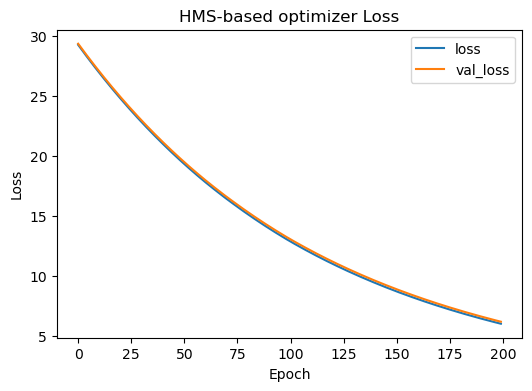

In [26]:
plt.figure(figsize=(6,4))
plt.plot(history_hms.history['loss'])
plt.plot(history_hms.history['val_loss'])
plt.title('HMS-based optimizer Loss')
#plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show()

<h2 style="color:blue" align="center">Validation with 10 Random Executions</h2>

In [27]:
num_exe = 10 
loss = [] 
loss_hms = []  

for i in tqdm(np.arange(num_exe)):    
    # Load data
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
    temp_model = get_model()
    temp_weights = temp_model.get_weights()    
    
    # Model without HMS    
    val_model = get_model()
    val_model.set_weights(temp_weights)    
    val_model.fit(X_train, y_train, epochs = num_epochs, verbose = 0, batch_size = batch_size) 
    scores = val_model.evaluate(X_test, y_test, verbose = 0)
    loss.append(round(scores, 4)) 

    # Model with HMS
    val_model_hms = get_model()
    val_model_hms.set_weights(temp_weights)     
    val_model_hms.fit(X_train, y_train, epochs = num_epochs, verbose = 0, callbacks=[CustomCallbackHMS(val_model_hms)], batch_size = batch_size) 
    scores_hms = val_model_hms.evaluate(X_test, y_test, verbose = 0)
    loss_hms.append(round(scores_hms, 4)) 
    #print('Execution ',i, 'is completed')  

results = pd.DataFrame(list(zip(loss, loss_hms)), columns = [opti_name, opti_name+'+HMS'])
results.to_csv('Results/Wine/'+opti_name+' summary.csv') 

100%|██████████| 10/10 [00:07<00:00,  1.28it/s]


In [28]:
print('----------------------------------------------') 
print(f'                {opti_name} vs {opti_name}+HMS     ')
print('----------------------------------------------')
print(f'Training set size     : {X_train.shape[0]} samples        ')
print(f'Batch size            : {batch_size} samples      ')
print('----------------------------------------------')
print(f'Training time for single run with {num_epochs} epochs')
print('----------------------------------------------')
print(f'{opti_name}           : {round(elapsed_training_time_generic,4)} seconds') 
print(f'{opti_name}+HMS       : {round(elapsed_training_time_hms,4)} seconds')
print('----------------------------------------------')
print(f'Training cost for single run                 ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(df1.iloc[num_epochs-1].loss, 4)}') 
print(f'{opti_name}+HMS       : {round(df2.iloc[num_epochs-1].loss, 4)}')
print('----------------------------------------------')
print(f'Testing cost for single run                 ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(generic_testing_cost, 4)}') 
print(f'{opti_name}+HMS       : {round(hms_testing_cost, 4)}')
print('----------------------------------------------')   
print('''Test set loss on different runs with different 
          weights initilization''')
print('----------------------------------------------')
print(results)
print('----------------------------------------------')
print('            Average loss with test set        ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(results[results.columns[0]].mean(),4)} (+- {round(results[results.columns[0]].std(),4)})')
print(f'{opti_name}+HMS       : {round(results[results.columns[1]].mean(),4)} (+- {round(results[results.columns[1]].std(),4)})')
print('----------------------------------------------') 
print('       Model that produces minimum loss       ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(results[results.columns[0]].min(),4)}')
print(f'{opti_name}+HMS       : {round(results[results.columns[1]].min(),4)}')
print('----------------------------------------------') 

----------------------------------------------
                SGD vs SGD+HMS     
----------------------------------------------
Training set size     : 3918 samples        
Batch size            : 3918 samples      
----------------------------------------------
Training time for single run with 200 epochs
----------------------------------------------
SGD           : 0.6675 seconds
SGD+HMS       : 0.3871 seconds
----------------------------------------------
Training cost for single run                 
----------------------------------------------
SGD           : 7.7801
SGD+HMS       : 6.0578
----------------------------------------------
Testing cost for single run                 
----------------------------------------------
SGD           : 7.9493
SGD+HMS       : 6.2052
----------------------------------------------
Test set loss on different runs with different 
          weights initilization
----------------------------------------------
       SGD  SGD+HMS
0   9.4536   7.3

#### Release the GPU memory

In [29]:
from numba import cuda 
device = cuda.get_current_device()
device.reset()